In [1]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

kernel_sizes = [101]
field_sizes = [40, 50, 70, 80, 100, 120, 150, 200, 250, 300, 350, 400]
results =  []

machine_config = MachineConfig(
    preset="../../src/pydose_rt/data/machine_presets/umea_10MV.json"
)
resolution = (4.0, 4.0, 4.0)
ct_array_shape = (100, 100, 100)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
for kernel_size in kernel_sizes:
    kernel_res = []
    beam_template = Beam.create(
        gantry_angle_deg=0.0, 
        number_of_leaf_pairs=60, 
        collimator_angle_deg=0.0, 
        field_size_mm=(100, 100), 
        iso_center=(0.0, -102.0, 0.0), 
        device=device, 
        dtype=dtype)
    dose_engine = DoseEngine(
        machine_config, 
        kernel_size,
        resolution=phantom._resolution,
        image_template=phantom.density_image,
        beam_template=beam_template,
        device=device,
        dtype=dtype,
        adjust_values=False
    )
    dose_engine.calibrate(110)
    for field_size in field_sizes:
        number_of_beams=1
        starting_angle=0

        beam = Beam.create(
            gantry_angle_deg=0.0, 
            number_of_leaf_pairs=60, 
            collimator_angle_deg=0.0, 
            field_size_mm=(field_size, field_size), 
            iso_center=(0.0, -102.0, 0.0), 
            device=device, 
            dtype=dtype)
        beam.mu = 110 * beam.mu

        dose = dose_engine.compute_dose(
            beam,
            ct_image=phantom.density_image).detach()
        # plt.plot(dose[0, 50, :, 50].cpu().detach().numpy())
        # plt.show()
        kernel_res.append(dose[0, *dose_engine.iso_center_voxel].item())
    results.append(kernel_res)
                            

Calibration failed. Adjusting calibration factor to: 0.004140962848896503


In [2]:
field_sizes = [40, 50, 70, 80, 100, 120, 150, 200, 250, 300, 350, 400]
of_measurements = [    0.884,
    0.912,
    0.955,
    0.971,
    1.000,
    1.021,
    1.045,
    1.075,
    1.096,
    1.111,
    1.123,
    1.130
]
modelled = results[0]

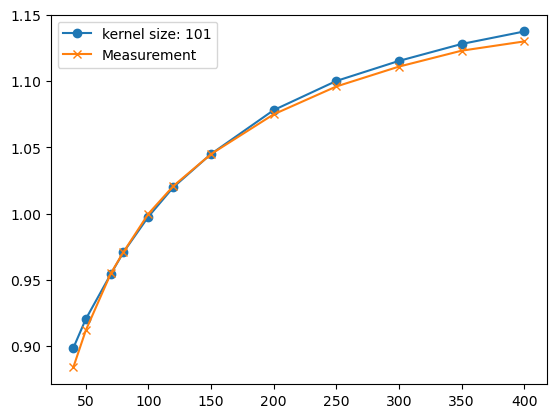

In [3]:
for index, result in enumerate(results):
    plt.plot(field_sizes, result, label=f"kernel size: {kernel_sizes[index]}", marker='o')
    plt.plot(field_sizes, of_measurements, label=f"Measurement", marker='x')
plt.legend()

In [4]:
corrections = np.array(of_measurements) / np.array(results[0])
corrections = corrections / corrections[4]

In [ ]:

profiles = np.round(np.stack([field_sizes, corrections], 0), 4)

def fmt(x):
    s = np.format_float_positional(x, trim='-')
    return s if '.' in s else s + '.0'

formatted = np.array2string(
    profiles,
    formatter={'float_kind': fmt},
    separator=', '       # ← comma between values
)

print(formatted)

[[40.0, 50.0, 70.0, 80.0, 100.0, 120.0, 150.0, 200.0, 250.0, 300.0, 350.0,
  400.0],
 [0.9816, 0.9886, 0.9983, 0.998, 1.0, 0.9987, 0.9977, 0.9949, 0.994,
  0.994, 0.9933, 0.9912]]


: 